# 01 Iron anode (IA-FE-001)

**Requirement:** `IA-FE-001`

Patents: US12308414B2, EP4602674A1. Equations are paraphrased; see claims/paragraphs cited below.

## Governing equations

Discharge of metallic iron in alkaline electrolyte (EP4602674A1 [0042]-[0043] Eq. 1),
theoretical capacity $960\,\mathrm{mAh\,g^{-1}}$ Fe:

$$\mathrm{Fe} + 2\,\mathrm{OH^-} \leftrightarrow \mathrm{Fe(OH)_2} + 2\,\mathrm{e^-}$$

Second discharge step (Eq. 2), $320\,\mathrm{mAh\,g^{-1}}$ Fe:

$$3\,\mathrm{Fe(OH)_2} + 2\,\mathrm{OH^-} \leftrightarrow \mathrm{Fe_3O_4} + 4\,\mathrm{H_2O} + 2\,\mathrm{e^-}$$

Faraday: $r = I/(nF)$, $n=2$. Butler-Volmer current from `ironair.chemistry.kinetics`.
Porosity absorbs the solid volume increase (IA-SYS-020). DRI beds, porous particles, and
channeled ribs (EP Claim 1; loading $1$–$7\,\mathrm{g\,cm^{-2}}$, VF $0.5$–$0.9$) share this RHS.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

here = Path.cwd()
for cand in (here, here.parent):
    if (cand / "src" / "ironair").is_dir() and (cand / "plant_sim").is_dir():
        sys.path.insert(0, str(cand))
        sys.path.insert(0, str(cand / "src"))
        break

from plant_sim.bootstrap import setup_path

setup_path()
from plant_sim.params import CAPACITY_FE_OH2_MAH_G, CAPACITY_MAGNETITE_MAH_G, default_params

In [2]:
from IPython import get_ipython

_ipy = get_ipython()
if _ipy is not None:
    _ipy.run_line_magic("matplotlib", "inline")

sns.set(
    rc={
        "axes.labelsize": 12,
        "axes.titlesize": 18,
        "figure.figsize": (11, 8.5),
        "figure.dpi": 300,
        "figure.facecolor": "w",
        "figure.edgecolor": "k",
    }
)
P = default_params()
print("KOH default", P.c_KOH_mol_m3 / 1000, "M; T_ep", P.T_ep_sim_K, "K")
print("Faraday 960/320 checks", round(CAPACITY_FE_OH2_MAH_G, 2), round(CAPACITY_MAGNETITE_MAH_G, 2))

KOH default 6.0 M; T_ep 303.15 K
Faraday 960/320 checks 959.85 319.95


## Simulation setup

Integrate the model once. Plot sections below each document what is shown, why it matters for patent/requirement verification, and the equations that govern that view.


In [3]:
from plant_sim.components.iron_anode import IronAnode
from plant_sim.components.base import integrate_component

fe = IronAnode(P)
I = 40 * P.I_discharge_100h_A
t, y = integrate_component(
    lambda t, y: fe.rhs(t, y, {"I_fe_A": I, "T_amb_K": P.T_ep_sim_K, "a_oh": 6.0, "a_h2o": 0.72}, {}),
    fe.y0(),
    (0, 4000),
    n_eval=200,
)

## Iron phase inventories vs time

### What this plot illustrates

Shows conversion of metallic iron through $\mathrm{Fe(OH)_2}$ toward $\mathrm{Fe_3O_4}$ under an accelerated discharge current. An engineer checks that Fe decreases while $\mathrm{Fe(OH)_2}$ rises first (EP4602674A1 [0042]–[0043]), matching the Faraday map used by `IronAnode`.

### Governing equations

$$\mathrm{Fe} + 2\,\mathrm{OH^-} \leftrightarrow \mathrm{Fe(OH)_2} + 2\,\mathrm{e^-}$$

$$3\,\mathrm{Fe(OH)_2} + 2\,\mathrm{OH^-} \leftrightarrow \mathrm{Fe_3O_4} + 4\,\mathrm{H_2O} + 2\,\mathrm{e^-}$$

Rate from current: $r = I/(nF)$ with $n=2$. Capacity targets: $960\,\mathrm{mAh\,g^{-1}}$ (to $\mathrm{Fe(OH)_2}$) and $320\,\mathrm{mAh\,g^{-1}}$ (to $\mathrm{Fe_3O_4}$).


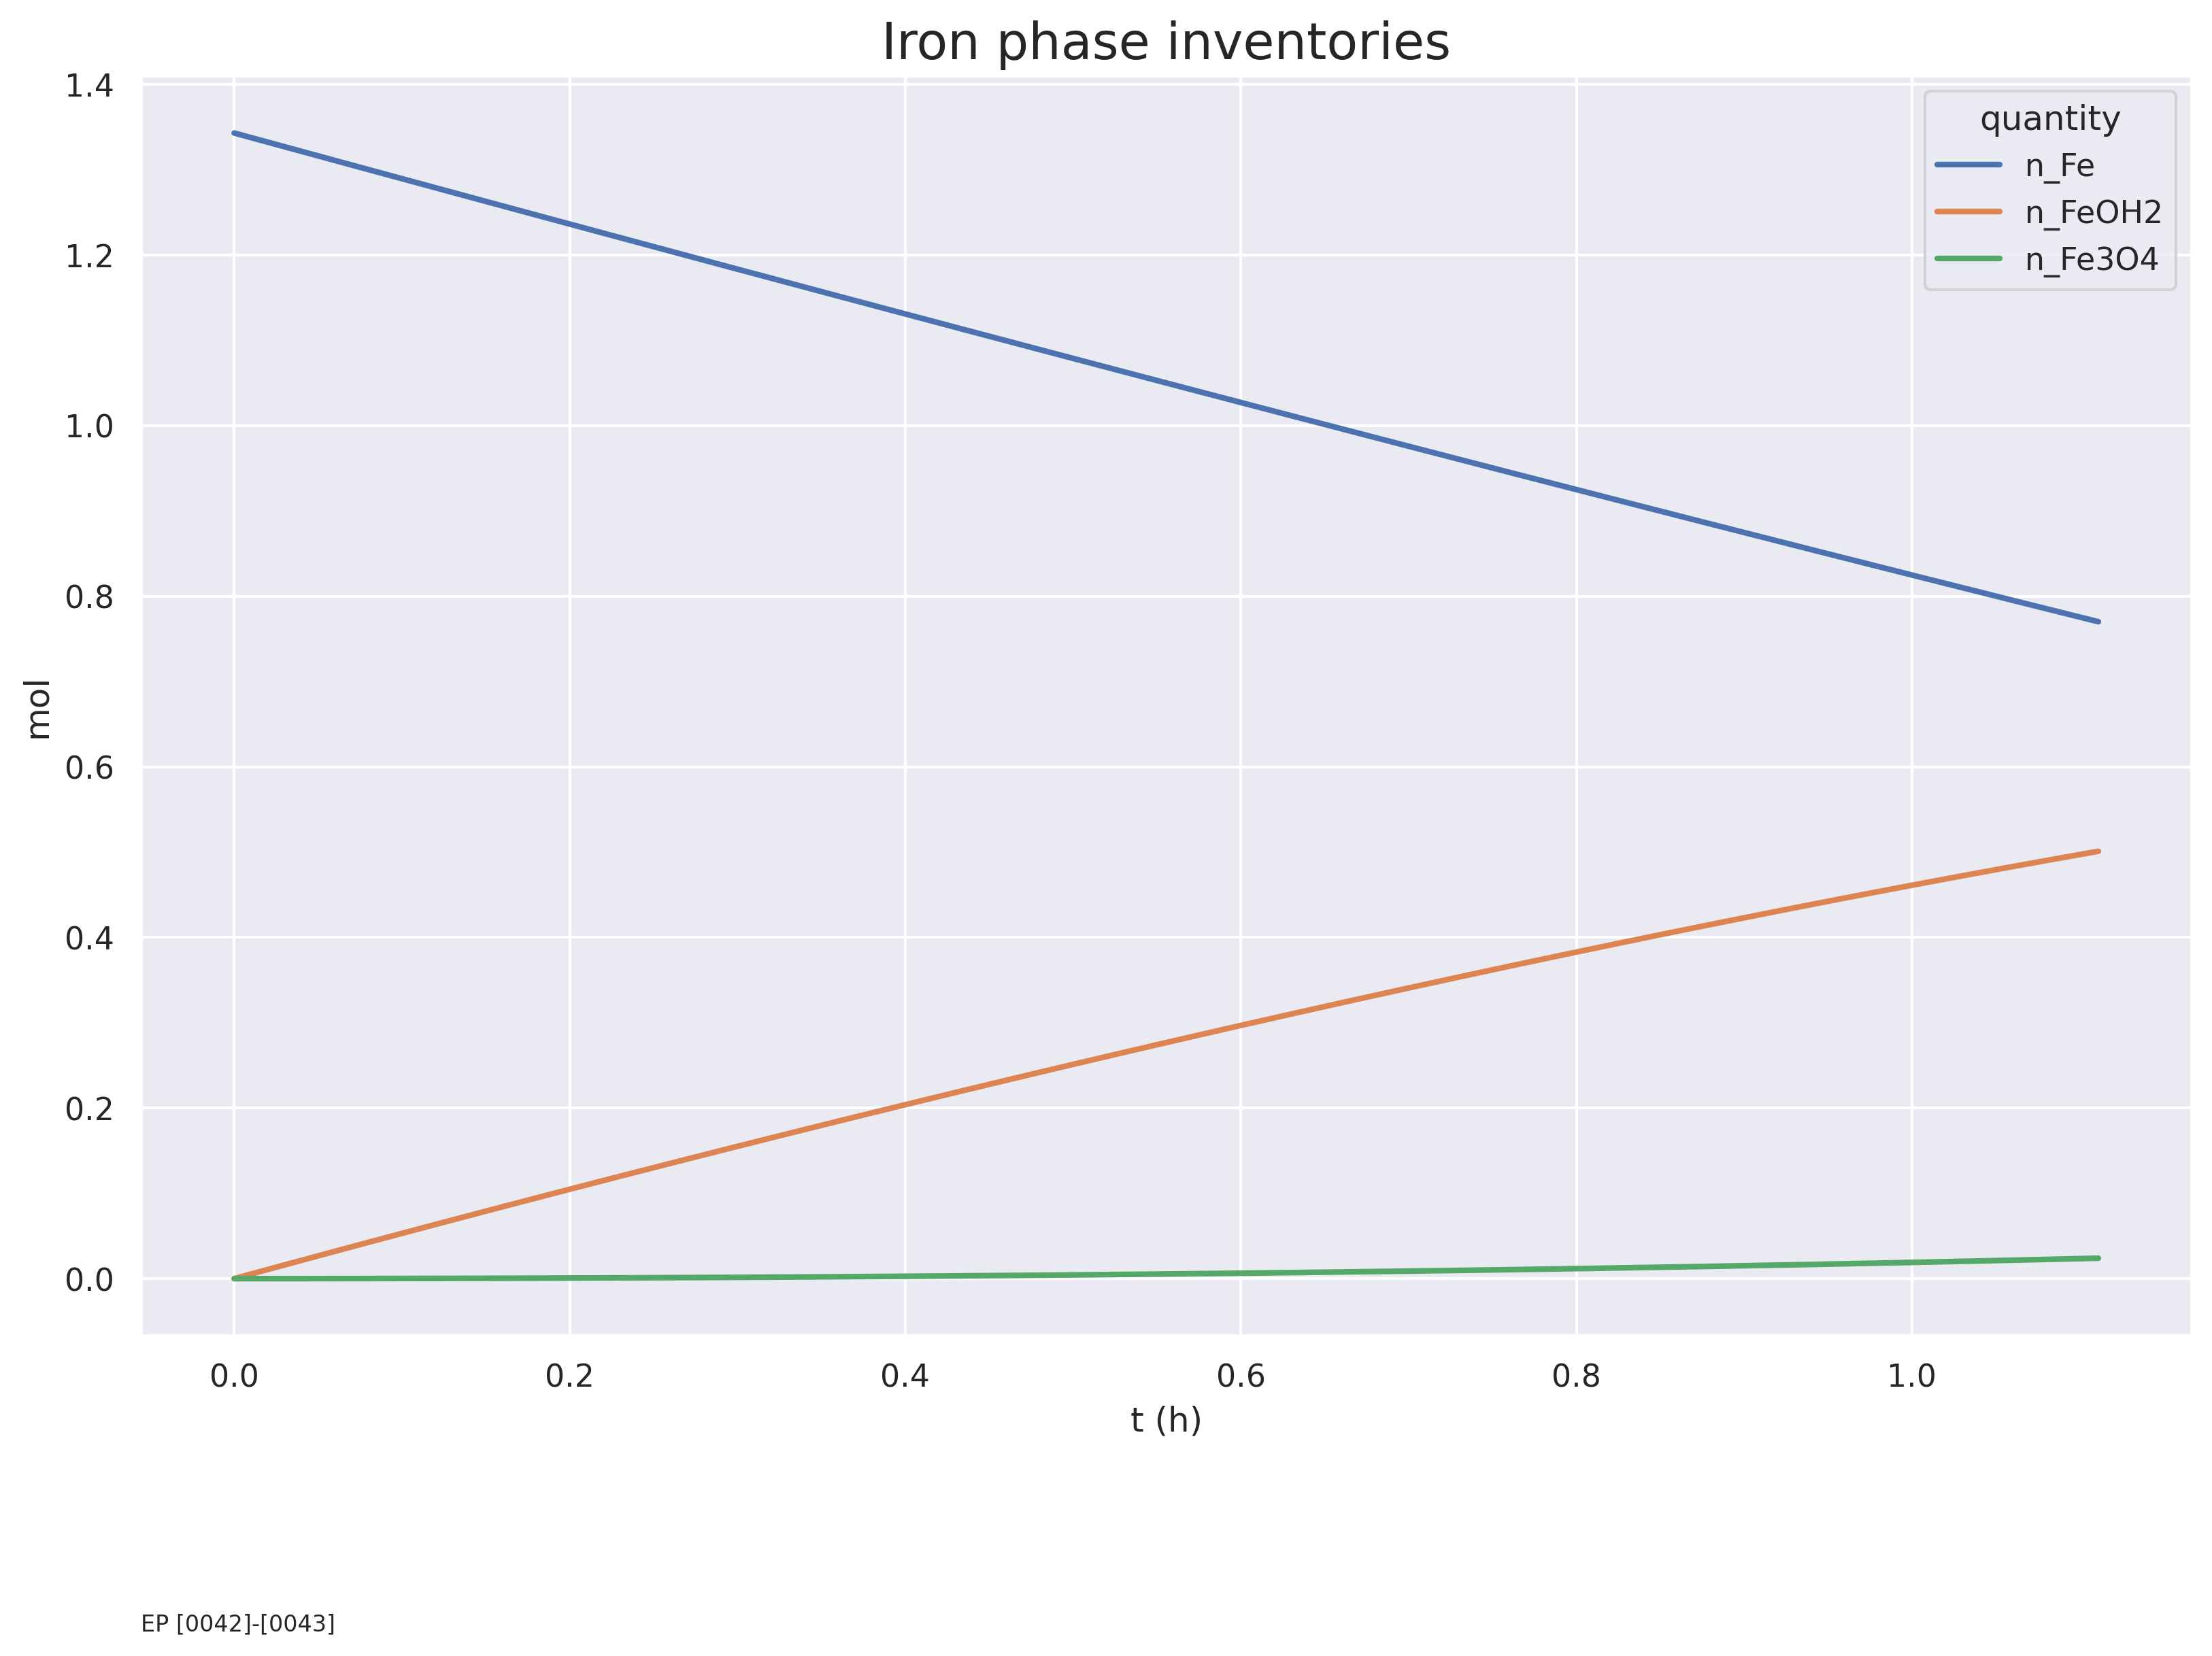

In [4]:
plot_frame = pd.DataFrame(
    {
        "t": (t / 3600),
        "n_Fe": (y[0]),
        "n_FeOH2": (y[1]),
        "n_Fe3O4": (y[2]),
    }
)
plot_long = plot_frame.melt(id_vars="t", var_name="quantity", value_name="value")
fig, ax = plt.subplots()
sns.lineplot(data=plot_long, x="t", y="value", hue="quantity", ax=ax, linewidth=2.0)
ax.set_xlabel("t (h)")
ax.set_ylabel("mol")
ax.set_title("Iron phase inventories")
ax.text(0.0, -0.22, "EP [0042]-[0043]", transform=ax.transAxes, fontsize=8, va="top")
fig.tight_layout()
fig.subplots_adjust(bottom=0.22)

## Numerical checks

Finite-trajectory and capacity checks for the integration above.


In [5]:
cap = [
    fe.outputs(float(ti), y[:, i], {"I_fe_A": I, "a_oh": 6.0, "a_h2o": 0.72}, {})["capacity_extracted_mAh_g"]
    for i, ti in enumerate(t)
]
print("extracted mA h g⁻¹ (accelerated)", cap[-1], "theory 960 =", CAPACITY_FE_OH2_MAH_G)

extracted mA h g⁻¹ (accelerated) 409.47218445659905 theory 960 = 959.8524897614429


## Verification against patents / SSS002

In [6]:
assert abs(CAPACITY_FE_OH2_MAH_G - 960) < 1.0
assert abs(CAPACITY_MAGNETITE_MAH_G - 320) < 1.0
print("PASS Faraday capacities")
print("loading", P.loading_g_cm2, "g cm⁻² in [1, 7]; VF", P.vf_electrolyte_charged, "in [0.5, 0.9]")

PASS Faraday capacities
loading 3.0 g cm⁻² in [1, 7]; VF 0.7 in [0.5, 0.9]
